# QELC v2 — Quantum-Enhanced Liquidity Clearinghouse (corrected pipeline)

Fujitsu Quantum Simulator Challenge 2026 — IIT Patna.

This notebook demonstrates the **corrected** netting pipeline from the `qelc` package.
What changed vs the original prototype (`crazy-simulator.ipynb`):

| # | Old | New |
|---|-----|-----|
| 1 | Cost layer = all-qubit `DiagonalMatrix` built from a full $2^n$ classical diagonal (brute force in disguise; unsupported on the FX700 distributed backend) | Gate-based cost layer (RZ + CNOT·RZ·CNOT), $O(n+|E|)$ gates/layer, expectation via `Observable` |
| 2 | Solution = `most_common(1)` of 100 unseeded samples (≈ a random draw) | Seeded 10k-shot sampling → exact rescoring → feasible-min → greedy repair |
| 3 | Log-scaled weights (optimum ≠ max dollars) | Linear max-normalized weights |
| 4 | Savings over-counted for overlapping selections; "toxic cycle" hack deleted real debt edges | Residual-capacity execution + exclusion sets; independent ledger audit |
| 5 | Mixed 28 ERC-20 tokens as "$" | Per-token semantics + seeded Barabási–Albert synthetic graphs |
| 6 | No baselines | Greedy MWIS / exact / random+repair baselines, approximation ratios, $P(\text{optimal})$ |

Every stochastic step is seeded — rerunning this notebook reproduces identical numbers.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qelc.data import barabasi_debt_graph, enumerate_cycles, select_top_k_hub
from qelc.qubo import build_qubo, qubo_to_ising
from qelc.classical import brute_force_optimum, greedy_mwis, random_baseline
from qelc.qaoa import solve_qaoa
from qelc.engine import PeelingConfig, run_peeling, audit_log, report_table
from qelc.engine.metrics import p_optimal

MASTER_SEED = 42
K = 18          # batch size = qubit count (kept small for laptop runtimes; FX700 goes to 30+)
P_DEPTH = 2

## 1. Debt network

Synthetic **Barabási–Albert** scale-free debt graph (the topology the proposal promised):
random edge orientation, 50% reciprocal obligations, log-normal weights.
For real data, use the per-token loader — netting across mixed ERC-20 tokens is invalid
(USDC has 6 decimals, token prices differ by orders of magnitude):

```python
from qelc.data import load_token_transfers, build_debt_graph, list_tokens
print(list_tokens("../data/token_transfers.csv").head(10))   # pick ONE token
edges = load_token_transfers("../data/token_transfers.csv",
                             token_address="0x…", decimals=6)  # e.g. USDC
G, node_map = build_debt_graph(edges)
```


In [2]:
G = barabasi_debt_graph(150, m=4, reciprocal_frac=0.5, seed=MASTER_SEED)
gross = sum(d["weight"] for _, _, d in G.edges(data=True))
print(f"graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges, gross debt {gross:,.0f}")

graph: 150 nodes, 876 edges, gross debt 92,288


## 2. Rich cycles in the dense hub → MWIS QUBO

Cycles are scored by their minimum edge weight (the nettable amount). We restrict to cycles
through the **top hub node** — that is where cycles overlap heavily, producing the dense
conflict structure that makes selection genuinely hard (unrestricted top-K is nearly
conflict-free and trivial).

Two cycles **conflict** if they share a directed edge; selecting the best non-conflicting
subset is **Maximum-Weight Independent Set** on the conflict graph. Penalty
$P_{ij} = \min(w_i, w_j) + \varepsilon$ makes every QUBO optimum feasible
(switching off the lighter endpoint of any violated conflict strictly lowers the cost —
proof in `qelc/qubo/builder.py`, property-tested in `tests/test_penalty_dominance.py`).

In [3]:
cycles = enumerate_cycles(G, length_bound=5)
top = select_top_k_hub(G, cycles, K, n_hubs=1)
qubo = build_qubo(top)
print(f"{len(cycles)} cycles total; K={qubo.n} hub cycles selected; {len(qubo.quadratic)} conflicts")

7805 cycles total; K=18 hub cycles selected; 37 conflicts


## 3. Solve: QAOA vs classical baselines

- **exact** — certified optimum (vectorized brute force; the *verifier*, not the solver);
- **greedy** — the classical heuristic the proposal claims to beat;
- **random** — uniform samples through the *same* extraction/repair pipeline as QAOA
  (the null hypothesis: if QAOA doesn't beat this, its distribution carries no information);
- **qaoa** — gate-based QAOA, p=1 grid → COBYLA → INTERP to p=2, multi-start, seeded sampling.

In [4]:
solutions = {"exact": brute_force_optimum(qubo)}
opt = solutions["exact"]
solutions["greedy"] = greedy_mwis(qubo)
solutions["random"] = random_baseline(qubo, n_samples=10_000, seed=MASTER_SEED)
solutions["qaoa"], qaoa_levels = solve_qaoa(qubo, p=P_DEPTH, n_starts=4, maxiter=100,
                                            n_shots=10_000, seed=MASTER_SEED)
report_table(solutions, opt)

,solver,feasible,savings,qubo_cost,n_selected,wall_time_s,source,approx_ratio
0,exact,True,949.961610,-4.129671,7,0.1229,exact,1.00000
1,greedy,True,854.547655,-3.714888,6,0.0000,greedy,0.89956
2,random,True,949.961610,-4.129671,7,0.1817,random-repaired,1.00000
3,qaoa,True,949.961610,-4.129671,7,2410.2834,qaoa,1.00000


In [5]:
from qelc.qaoa import sample_bitstrings
from qelc.qubo import qubo_to_ising

isg = qubo_to_ising(qubo)
best = min(qaoa_levels, key=lambda r: r.energy)
samples = sample_bitstrings(isg, best.params, n_shots=10_000, seed=MASTER_SEED)
print(f"P(optimal bitstring in QAOA samples) = {p_optimal(samples, qubo, opt.qubo_cost):.4f}")
for r in qaoa_levels:
    print(f"p={r.p}: <H> = {r.energy:.4f}  ({r.n_evals} evals, {r.wall_time:.1f}s)")

P(optimal bitstring in QAOA samples) = 0.0132
p=1: <H> = -2.2548  (165 evals, 497.3s)
p=2: <H> = -2.8651  (400 evals, 1187.4s)


## 4. Iterative peeling engine (with audit)

The full clearinghouse loop: select → solve → execute at *residual* capacity → repeat.
The same engine runs every solver, so the end-to-end comparison is fair. An independent
auditor replays the execution log against the pristine ledger (no phantom edges, no
overdrafts, net positions preserved, totals match).

In [6]:
reports = {}
for solver in ("greedy", "qaoa"):
    cfg = PeelingConfig(k=K, p=1, max_iters=8, solver=solver, master_seed=MASTER_SEED,
                        n_starts=2, maxiter=60, n_shots=4_000)
    reports[solver] = run_peeling(G, cfg)
    audit = audit_log(G, reports[solver].log, reports[solver].total_cleared)
    r = reports[solver]
    print(f"{solver:>6}: cleared {r.total_cleared:,.0f} | gross reduction {r.gross_reduction:,.0f} "
          f"({r.netting_efficiency_pct:.1f}% of {r.initial_debt:,.0f}) | "
          f"{r.n_cycles_executed} cycles | audit {'PASS' if audit['passed'] else 'FAIL'}")

greedy: cleared 9,880 | gross reduction 27,037 (29.3% of 92,288) | 107 cycles | audit PASS


  qaoa: cleared 9,847 | gross reduction 26,646 (28.9% of 92,288) | 106 cycles | audit PASS


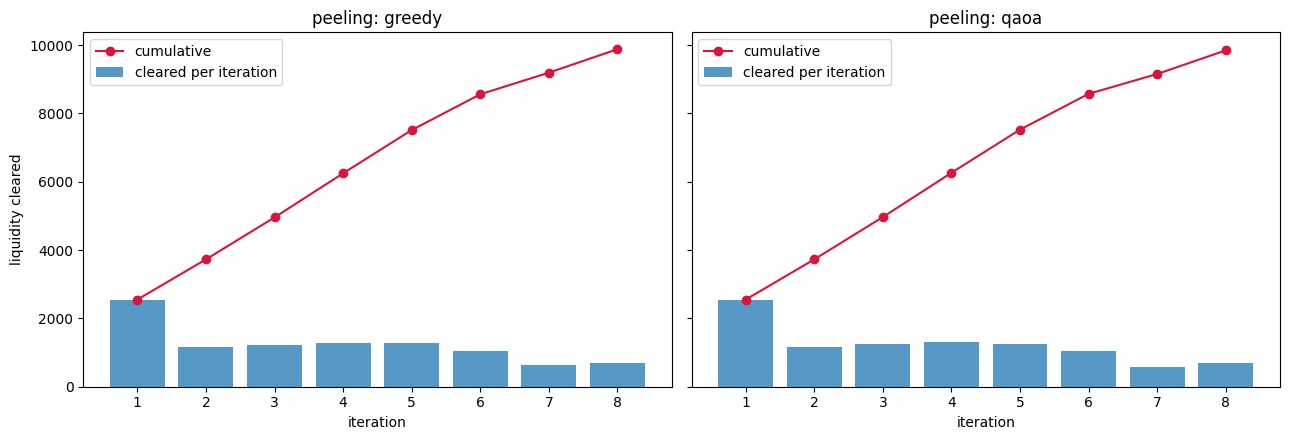

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (solver, rep) in zip(axes, reports.items()):
    iters = [s["iteration"] for s in rep.iteration_stats]
    cleared = [s["cleared"] for s in rep.iteration_stats]
    ax.bar(iters, cleared, alpha=0.75, label="cleared per iteration")
    ax.plot(iters, np.cumsum(cleared), "o-", color="crimson", label="cumulative")
    ax.set_title(f"peeling: {solver}")
    ax.set_xlabel("iteration"); ax.legend()
axes[0].set_ylabel("liquidity cleared")
plt.tight_layout(); plt.show()

## 5. Module II — Grover key-search scaling & the QVI

What actually runs on a quantum simulator: **Grover key search** at increasing key sizes,
built exclusively from FX700-supported gates (Toffolis decomposed to H/T/CNOT; V-chain
ancillas). Measured success probabilities must match $\sin^2((2m{+}1)\theta)$, and the
wall-time curve *is* the exponential wall that makes 128-bit keys already quantum-safe in
any practical horizon — the empirical anchor for the security side of the QVI.

In [8]:
from qelc.qvi import grover_resources
res = grover_resources(range(4, 11), seed=MASTER_SEED)
res

,key_bits,sim_qubits,grover_iterations,gates_per_iteration,total_gates,success_prob,theory_prob,wall_time_s
0,4,5,3,117,351,0.9665,0.961319,0.0004
1,5,7,4,179,716,0.9985,0.999182,0.0006
2,6,9,6,249,1494,0.9950,0.996586,0.0015
3,7,11,8,308,2464,0.9945,0.995620,0.0038
4,8,13,12,372,4464,1.0000,0.999947,0.0144
5,9,15,17,438,7446,0.9995,0.999448,0.0358
6,10,17,25,504,12600,1.0000,0.999461,0.1475


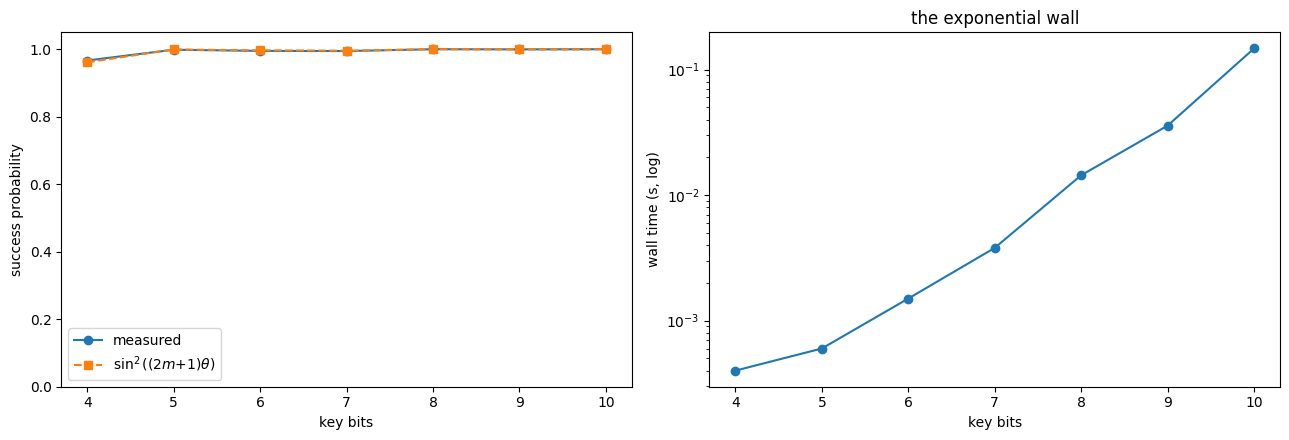

In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.plot(res.key_bits, res.success_prob, "o-", label="measured")
a1.plot(res.key_bits, res.theory_prob, "s--", label=r"$\sin^2((2m{+}1)\theta)$")
a1.set_xlabel("key bits"); a1.set_ylabel("success probability"); a1.legend(); a1.set_ylim(0, 1.05)
a2.semilogy(res.key_bits, res.wall_time_s, "o-")
a2.set_xlabel("key bits"); a2.set_ylabel("wall time (s, log)"); a2.set_title("the exponential wall")
plt.tight_layout(); plt.show()

### QVI with real inputs

`qvi_raw` is the proposal's original formula $\text{bits}^2/(\alpha\,\text{ops} + \beta\,\text{bw})$
fed with the NIST round-3 Dilithium reference costs — note it selects **Dilithium5**, because
Dilithium's costs grow ~linearly with level (not "exponentially" as the old report claimed).
`qvi_anchored` saturates the security utility at the mandated 192-bit compliance floor,
recovering the **Dilithium3** recommendation with a defensible economic argument.

In [10]:
from qelc.qvi import compute_qvi
compute_qvi(required_bits=192)

,level,nist_category,security_bits,attack_log2_gates,rel_compute_cost,rel_bandwidth_cost,qvi_raw,qvi_anchored,meets_requirement,recommended
0,Dilithium2,2,128,86.0,1.000,1.000,8192.0,8192.0,False,False
1,Dilithium3,3,192,118.0,1.570,1.405,12390.2,12390.2,True,True
2,Dilithium5,5,256,151.0,2.042,1.926,16516.5,9290.5,True,False


## 6. Next: scored runs on the FX700

Everything above runs locally. The **scored** competition results come from the QARP path —
see `fx700/README.md`: convention check (E0) → exactly-verified 24/26-qubit runs (E1/E2) →
single-node 30 qubits → multi-node 31–34 → strong scaling → QARP circuit-cutting demo (E10,
3 crossing conflicts ⇒ 3 gate cuts at p=1) → Grover scaling (G1).